# 02 - Text Preprocessing for CVE Descriptions

This notebook applies NLP preprocessing to CVE descriptions:
- Lowercasing
- Punctuation and special character removal
- Stopword removal (preserving security-relevant terms)
- Tokenization
- Lemmatization

Libraries: NLTK, spaCy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys
sys.path.append('..')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from utils.preprocessing import (
    clean_text, tokenize_text, remove_stopwords,
    lemmatize_tokens, preprocess_text
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## 1. Load the Dataset

In [2]:
df = pd.read_csv('../data/cve_explored.csv')
print(f"Loaded {len(df)} CVE records")
print(f"Columns: {list(df.columns)}")
df[['CVE ID', 'Description']].head()

Loaded 1314 CVE records
Columns: ['CVE ID', 'Description', 'CVSS Score', 'Attack Vector', 'Affected OS', 'Severity', 'Vulnerability_Type', 'Attack_Vector_Type', 'CVE_Year', 'Description_Length']


,CVE ID,Description
0,CVE-2024-21732,FlyCms through abbaa5a allows XSS via the perm...
1,CVE-2023-5877,The affiliate-toolkit WordPress plugin before ...
2,CVE-2023-6000,The Popup Builder WordPress plugin before 4.2....
3,CVE-2023-6037,The WP TripAdvisor Review Slider WordPress plu...
4,CVE-2023-6064,The PayHere Payment Gateway WordPress plugin b...


## 2. Examine Raw Descriptions

In [3]:
# Show a few raw descriptions
print("Sample raw CVE descriptions:")
print("=" * 80)
for i, row in df.head(5).iterrows():
    print(f"\n{row['CVE ID']}:")
    print(f"  {row['Description'][:200]}...")
    print(f"  Length: {len(str(row['Description']))} chars")

Sample raw CVE descriptions:

CVE-2024-21732:
  FlyCms through abbaa5a allows XSS via the permission management feature....
  Length: 72 chars

CVE-2023-5877:
  The affiliate-toolkit WordPress plugin before 3.4.3 lacks authorization and authentication for requests to it's affiliate-toolkit-starter/tools/atkp_imagereceiver.php endpoint, allowing unauthenticate...
  Length: 339 chars

CVE-2023-6000:
  The Popup Builder WordPress plugin before 4.2.3 does not prevent simple visitors from updating existing popups, and injecting raw JavaScript in them, which could lead to Stored XSS attacks....
  Length: 189 chars

CVE-2023-6037:
  The WP TripAdvisor Review Slider WordPress plugin before 11.9 does not sanitise and escape some of its settings, which could allow high privilege users such as admin to perform Stored Cross-Site Scrip...
  Length: 300 chars

CVE-2023-6064:
  The PayHere Payment Gateway WordPress plugin before 2.2.12 automatically creates publicly-accessible log files containing se

## 3. Step-by-Step Preprocessing Demo

Let's walk through each preprocessing step on a single CVE description.

In [4]:
# Demo with a sample description
sample_desc = df['Description'].iloc[0]
print(f"Original:\n  {sample_desc}\n")

# Step 1: Clean text
cleaned = clean_text(sample_desc)
print(f"After cleaning:\n  {cleaned}\n")

# Step 2: Tokenize
tokens = tokenize_text(cleaned)
print(f"After tokenization ({len(tokens)} tokens):\n  {tokens}\n")

# Step 3: Remove stopwords
no_stop = remove_stopwords(tokens)
print(f"After stopword removal ({len(no_stop)} tokens):\n  {no_stop}\n")

# Step 4: Lemmatize
lemmatized = lemmatize_tokens(no_stop)
print(f"After lemmatization ({len(lemmatized)} tokens):\n  {lemmatized}\n")

# Final result
final = ' '.join(lemmatized)
print(f"Final preprocessed text:\n  {final}")

Original:
  FlyCms through abbaa5a allows XSS via the permission management feature.

After cleaning:
  flycms through abbaa a allows xss via the permission management feature

After tokenization (11 tokens):
  ['flycms', 'through', 'abbaa', 'a', 'allows', 'xss', 'via', 'the', 'permission', 'management', 'feature']

After stopword removal (8 tokens):
  ['flycms', 'abbaa', 'allows', 'xss', 'via', 'permission', 'management', 'feature']

After lemmatization (8 tokens):
  ['flycms', 'abbaa', 'allows', 'xss', 'via', 'permission', 'management', 'feature']

Final preprocessed text:
  flycms abbaa allows xss via permission management feature


## 4. Apply Preprocessing to All Descriptions

In [5]:
from tqdm import tqdm
tqdm.pandas(desc="Preprocessing CVE descriptions")

# Apply full preprocessing pipeline
df['Cleaned_Description'] = df['Description'].progress_apply(preprocess_text)

# Show results
print("\nPreprocessing complete!")
print(f"Records processed: {len(df)}")
print(f"Empty after preprocessing: {(df['Cleaned_Description'] == '').sum()}")

# Compare original vs cleaned
df[['CVE ID', 'Description', 'Cleaned_Description']].head(5)

Preprocessing CVE descriptions: 100%|██████████| 1314/1314 [00:00<00:00, 2699.51it/s]


Preprocessing complete!
Records processed: 1314
Empty after preprocessing: 0


,CVE ID,Description,Cleaned_Description
0,CVE-2024-21732,FlyCms through abbaa5a allows XSS via the perm...,flycms abbaa allows xss via permission managem...
1,CVE-2023-5877,The affiliate-toolkit WordPress plugin before ...,affiliate toolkit wordpress plugin VERSION lac...
2,CVE-2023-6000,The Popup Builder WordPress plugin before 4.2....,popup builder wordpress plugin VERSION prevent...
3,CVE-2023-6037,The WP TripAdvisor Review Slider WordPress plu...,tripadvisor review slider wordpress plugin san...
4,CVE-2023-6064,The PayHere Payment Gateway WordPress plugin b...,payhere payment gateway wordpress plugin VERSI...


## 5. Token Frequency Analysis

Top 30 most frequent tokens after preprocessing:
  vulnerability: 1320
  VERSION: 837
  file: 561
  version: 548
  attacker: 487
  issue: 476
  user: 459
  lead: 412
  may: 407
  code: 331
  via: 313
  arbitrary: 274
  used: 256
  allows: 247
  affect: 247
  exploit: 240
  access: 238
  attack: 234
  found: 229
  site: 219
  system: 210
  could: 207
  public: 205
  manipulation: 203
  identifier: 203
  vdb: 200
  earlier: 200
  crafted: 199
  request: 197
  possible: 196


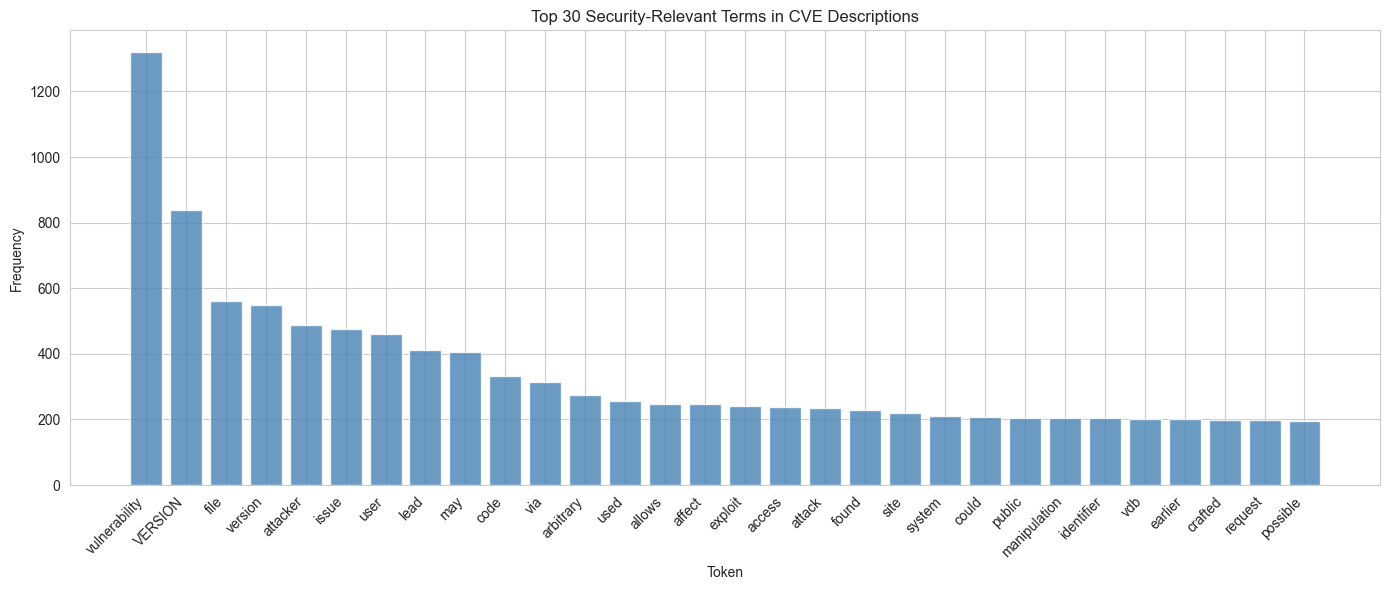

In [6]:
# Analyze most common tokens in preprocessed text
all_tokens = []
for text in df['Cleaned_Description']:
    all_tokens.extend(str(text).split())

token_counts = Counter(all_tokens)
top_30 = token_counts.most_common(30)

print("Top 30 most frequent tokens after preprocessing:")
for token, count in top_30:
    print(f"  {token}: {count}")

# Bar chart
plt.figure(figsize=(14, 6))
plt.bar([t[0] for t in top_30], [t[1] for t in top_30], color='steelblue', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Token')
plt.ylabel('Frequency')
plt.title('Top 30 Security-Relevant Terms in CVE Descriptions')
plt.tight_layout()
plt.show()

## 6. Word Cloud Visualization

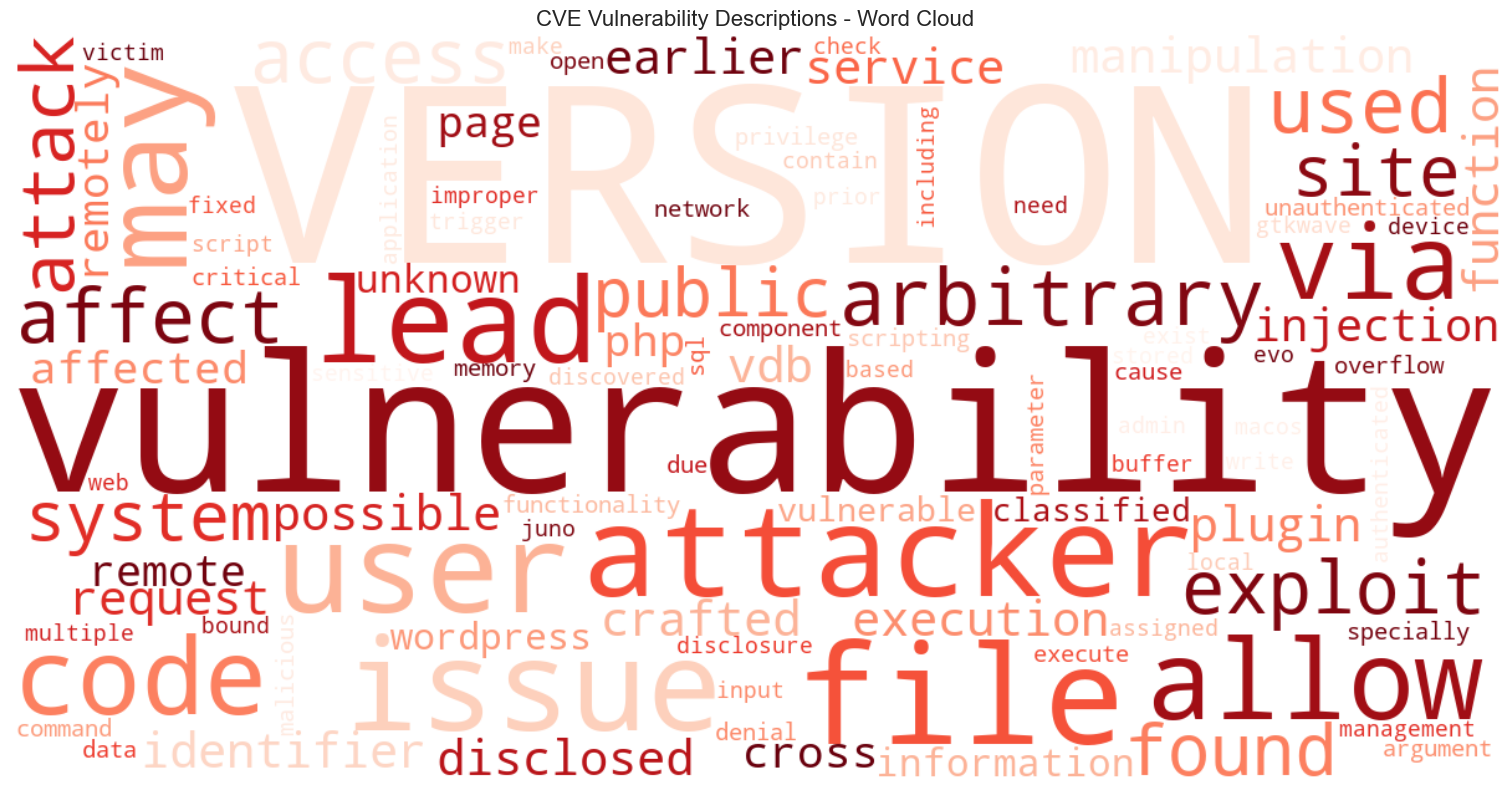

In [7]:
from wordcloud import WordCloud

all_text = ' '.join(df['Cleaned_Description'].dropna())

wordcloud = WordCloud(width=1200, height=600, background_color='white',
                      colormap='Reds', max_words=100,
                      collocations=False).generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('CVE Vulnerability Descriptions - Word Cloud', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Text Length Comparison (Before vs After)

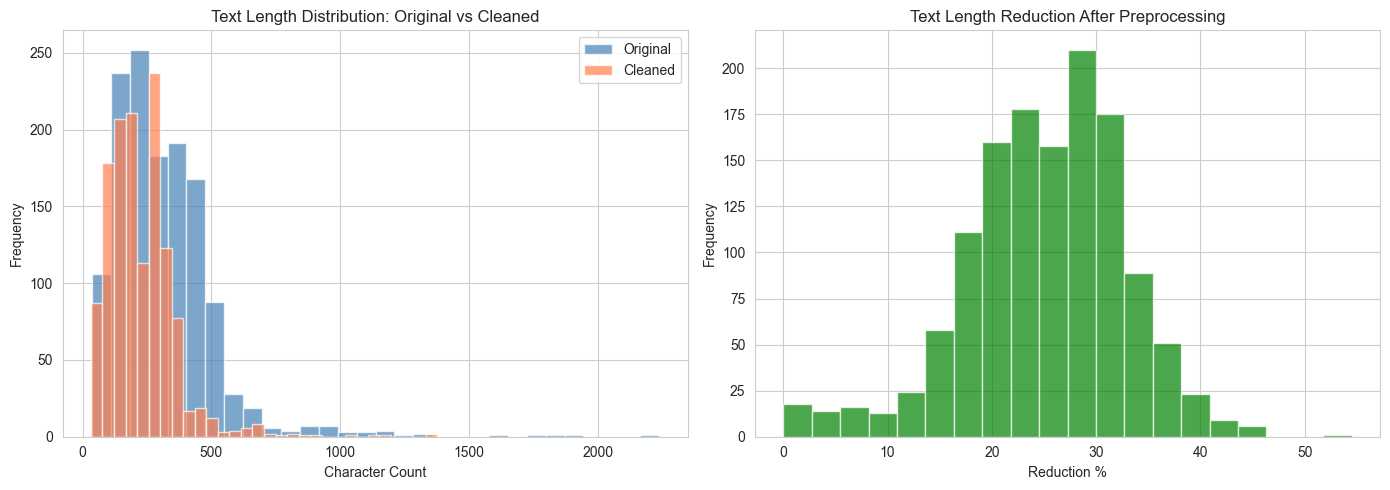

Average text reduction: 25.0%


In [8]:
df['Original_Length'] = df['Description'].str.len()
df['Cleaned_Length'] = df['Cleaned_Description'].str.len()
df['Reduction_Pct'] = ((df['Original_Length'] - df['Cleaned_Length']) / df['Original_Length'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Original_Length'], bins=30, alpha=0.7, label='Original', color='steelblue')
axes[0].hist(df['Cleaned_Length'], bins=30, alpha=0.7, label='Cleaned', color='coral')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution: Original vs Cleaned')
axes[0].legend()

axes[1].hist(df['Reduction_Pct'].dropna(), bins=20, color='green', alpha=0.7)
axes[1].set_xlabel('Reduction %')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length Reduction After Preprocessing')

plt.tight_layout()
plt.show()

print(f"Average text reduction: {df['Reduction_Pct'].mean():.1f}%")

## 8. Save Preprocessed Dataset

In [9]:
# Save preprocessed data
df.to_csv('../data/cve_preprocessed.csv', index=False)
print(f"Preprocessed dataset saved: {len(df)} records")
print(f"Columns: {list(df.columns)}")
print("\n✅ Text preprocessing complete!")

Preprocessed dataset saved: 1314 records
Columns: ['CVE ID', 'Description', 'CVSS Score', 'Attack Vector', 'Affected OS', 'Severity', 'Vulnerability_Type', 'Attack_Vector_Type', 'CVE_Year', 'Description_Length', 'Cleaned_Description', 'Original_Length', 'Cleaned_Length', 'Reduction_Pct']

✅ Text preprocessing complete!
